# Handling missing data

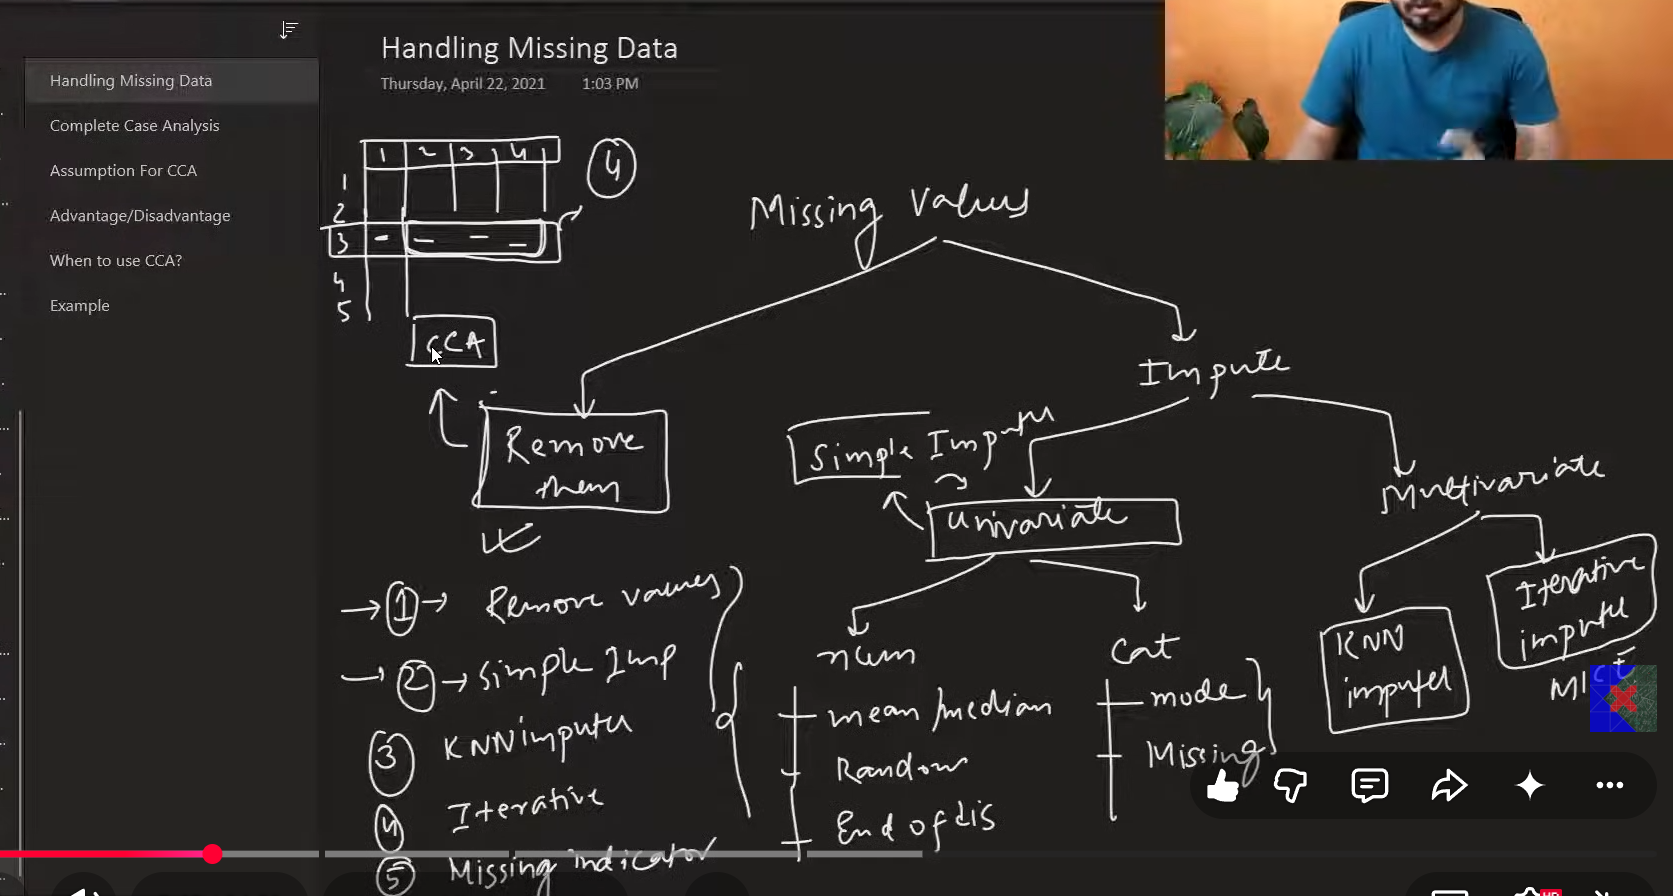

Comple Case Analysis(CCA)
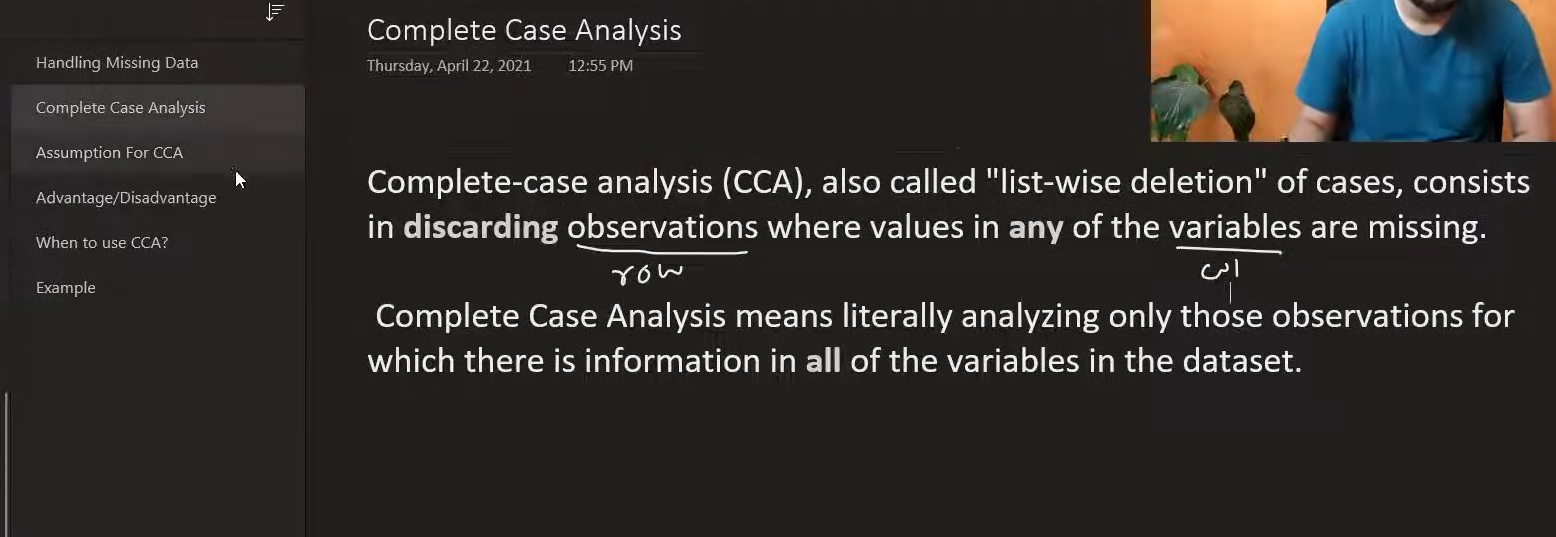
If any column value of any row is missing then we remove whole row that is called CCA

Assumption for CAA
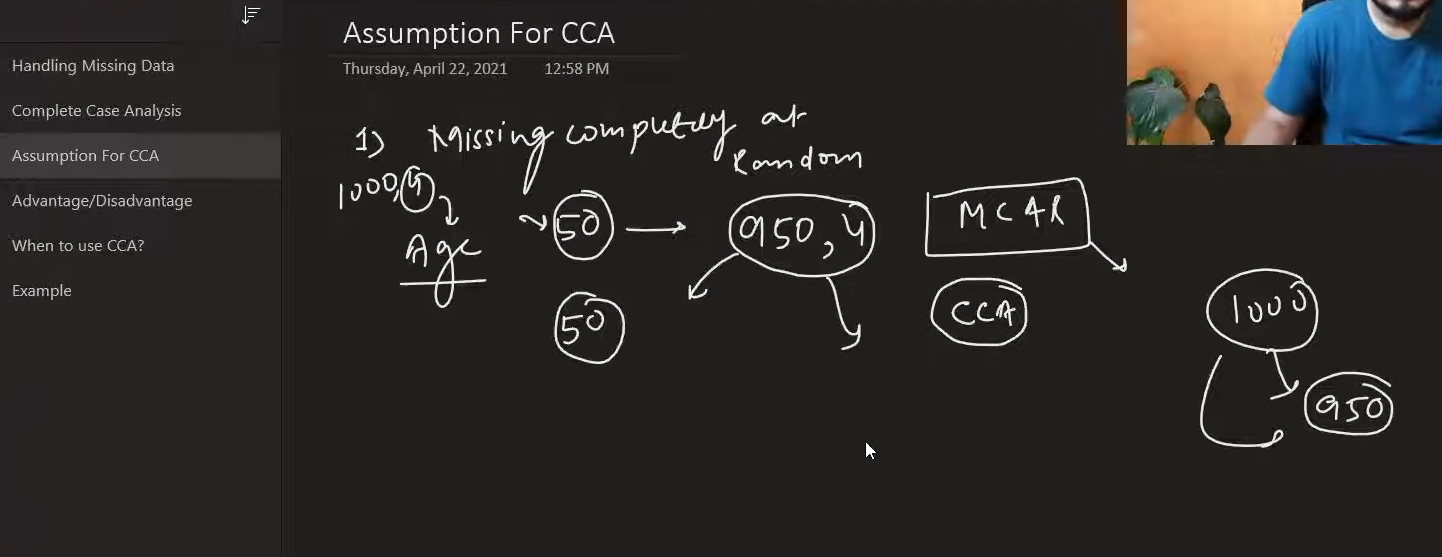
when data is missing randomly then we remove it  otherwise not 

Advantage/Disadvantage of CAA

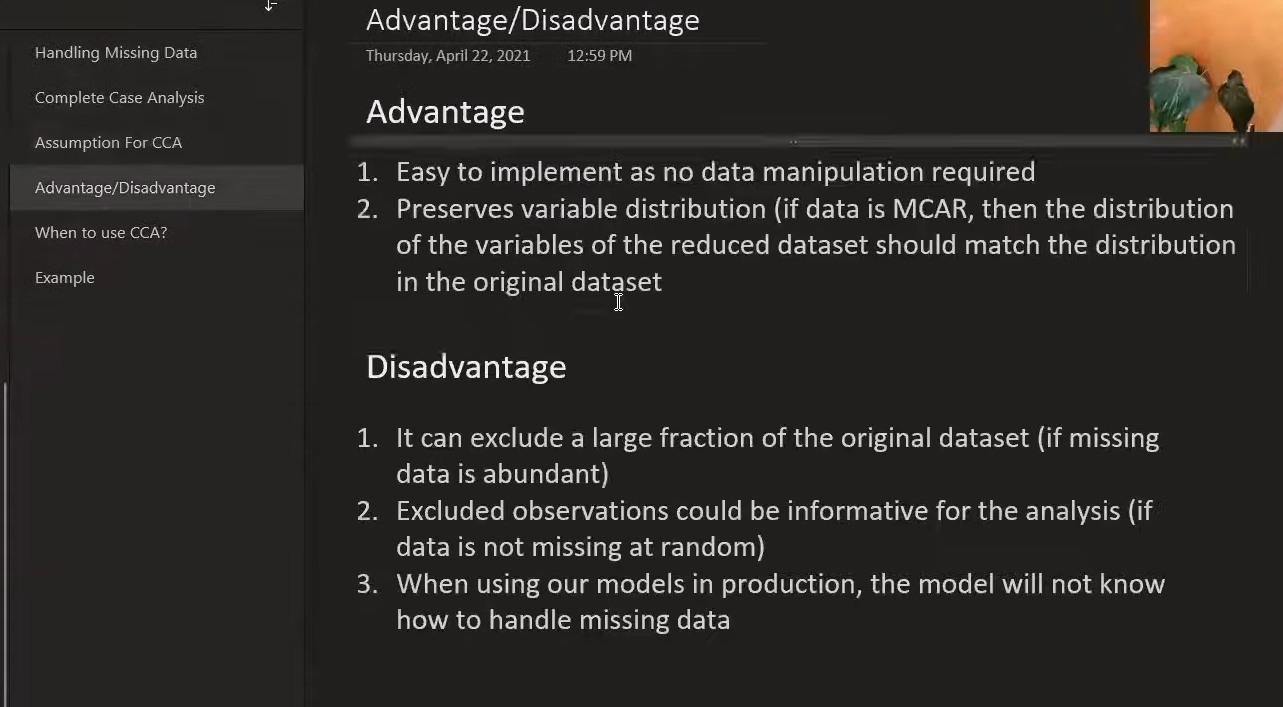

we always check distribution before and after  removing data. 

When to use CAA
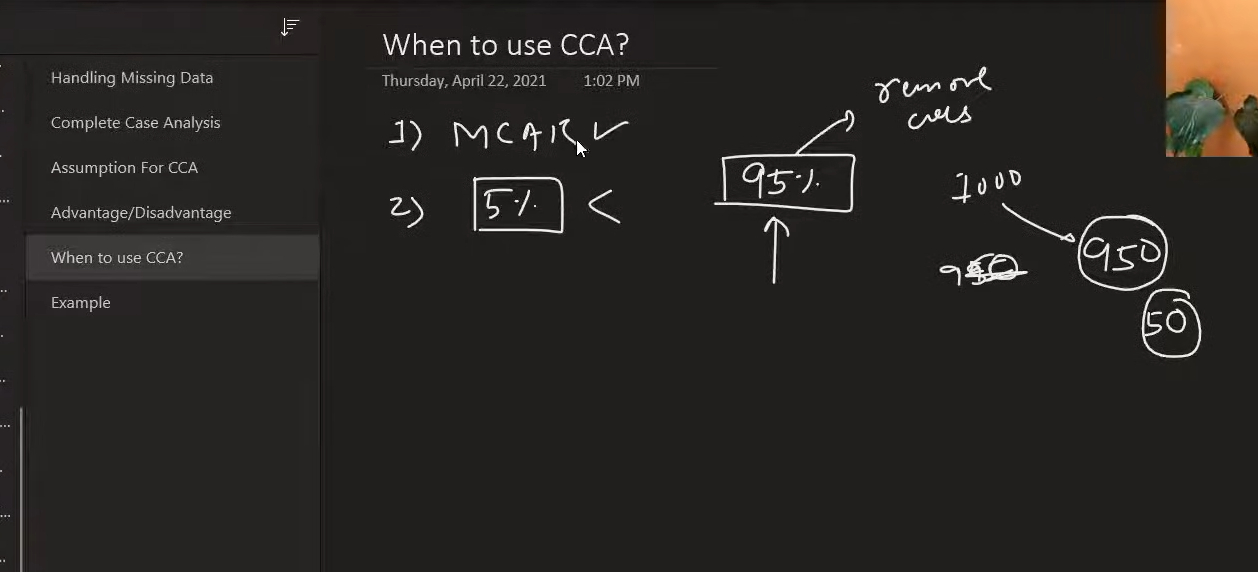
(1): Data should be mising at randomly 

(2): we use CAA when data missing is <5 percent and if in a column 90 percent data is missing then we remove the whole column

# Example

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv('data_science_job.csv')

In [6]:
df.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [11]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [12]:
df.shape

(19158, 13)

In [14]:
cols = [var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]

In [15]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [17]:
df'[cols'].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
170,0.855,no_enrollment,Masters,10.0,114.0
18649,0.555,Full time course,Graduate,4.0,2.0
2161,0.855,Full time course,Graduate,9.0,3.0
10796,0.762,no_enrollment,Graduate,17.0,27.0
7827,0.920,no_enrollment,Graduate,14.0,192.0


In [19]:
len(df[cols].dropna())/len(df)  ## the remaining data percentage  after removing those
# missing rows and by  taking its length division by original df length

0.8968577095730244

In [20]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

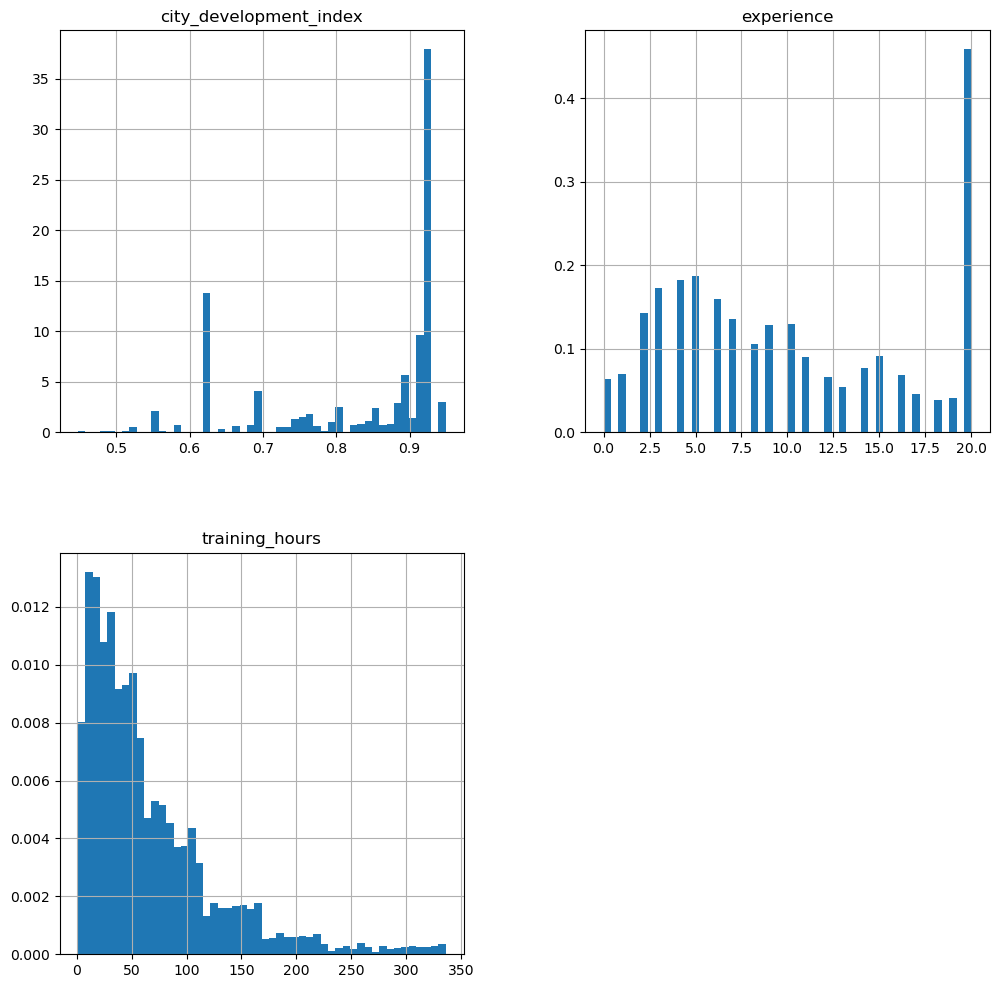

In [22]:
new_df.hist(bins = 50, density = True , figsize = (12,12))

<Axes: >

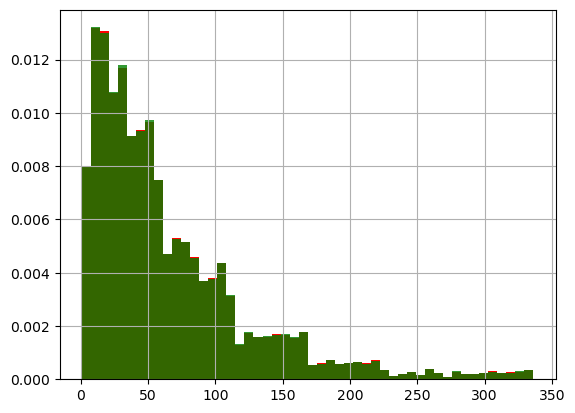

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours']. hist(bins = 50, ax=ax, density=True, color='red')


# data after cca the argument  alpha makes the color transparent , so 
# we can see the overlay  of the 2 distributions
new_df['training_hours']. hist(bins = 50, ax=ax, density=True, color='green',alpha =0.8)

<Axes: ylabel='Density'>

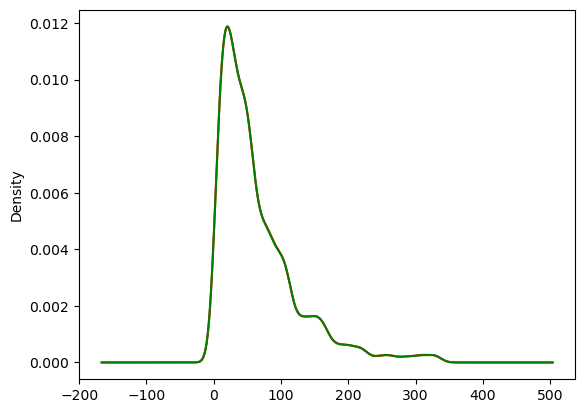

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca 
new_df['training_hours'].plot.density(color ='green')

<Axes: >

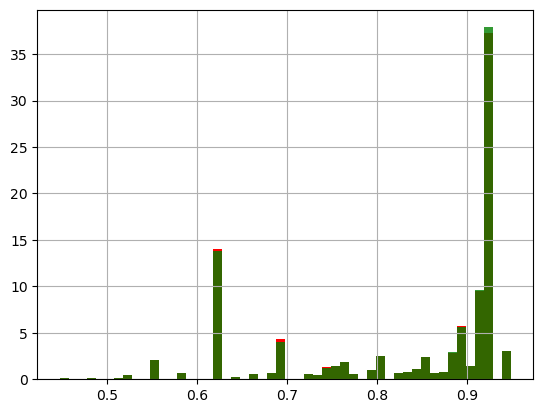

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index']. hist(bins = 50, ax=ax, density=True, color='red')


# data after cca the argument  alpha makes the color transparent , so 
# we can see the overlay  of the 2 distributions
new_df['city_development_index']. hist(bins = 50, ax=ax, density=True, color='green',alpha =0.8)

<Axes: ylabel='Density'>

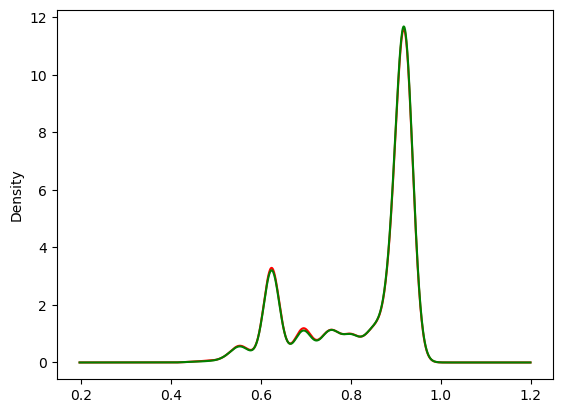

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca 
new_df['city_development_index'].plot.density(color ='green')

<Axes: ylabel='Density'>

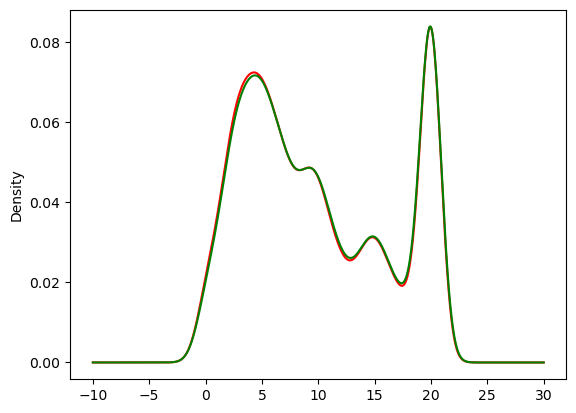

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca 
new_df['experience'].plot.density(color ='green')

In [32]:
temp = pd.concat([
    # percentage of observation per category ,original data
    df['enrolled_university'].value_counts()/len(df),

    # percentage of observation per category cca data
    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1
)

temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [33]:
temp = pd.concat([
    # percentage of observation per category ,original data
    df['education_level'].value_counts()/len(df),

    # percentage of observation per category cca data
    new_df['education_level'].value_counts()/len(new_df)
],axis=1
)

temp.columns = ['original', 'cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
